# U.S. GPA Growth Analysis: 

##  we will use the Least squares, polynomial fitting and cubic splines interpolation methods in order to estimate these missing data points 





# Introduction

This report will concern itself with the analysis of the U.S.'s GDP growth rates from 2010-2023. we will use 3 numerical methods and implement them entirely from scratch (no python libraries for help). The 3 consist of natural cubic spline interpolation,polynomial least squares using normal equations and a least squares linear regression (eliminating some outliers). each quarter will be an integer from 1-20 to aid in the building of our vandermonde matrices, and we will analyze the 3 different goals that each methods achieves the best. we will notice the cubic spline graph will pass through each point perfectly and have no RMSE value, the polynomial fit will be very malleable and will also have a reasonable error, and our linear least squares will have the lowest error and also the fastest run time. we will note each methods distinct trade-offs with respects to smoothness, sensitivity to outliers and computational cost (big O notation) and see things from the perspective of a policy maker to see which method is most desirable to use. 




In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import math
import time

quarters = [
    "2010 Q1","2011 Q1","2012 Q1","2013 Q1","2014 Q1","2014 Q3",
    "2015 Q2","2016 Q1","2016 Q3","2016 Q4","2017 Q1","2018 Q1",
    "2019 Q1","2020 Q1","2020 Q2","2020 Q3","2021 Q1","2022 Q1",
    "2023 Q2","2023 Q4"
]

x = np.array([i for i in range(1, 21)], dtype=float)

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0,
              3.0, 1.5, 3.5, 1.8, 1.3, 2.5,
              3.1, -5.1, -28.1, 33.8, 6.3, -1.6,
              2.4, 3.3], dtype=float)

print(f"number of data points: {len(x)}")
print(f"x range: {x[0]} to {x[-1]}")
print(f"y range: {y.min():.1f}% to {y.max():.1f}%")


number of data points: 20
x range: 1.0 to 20.0
y range: -28.1% to 33.8%


# Let us begin Part A using Cubic Spline Interpolation through a Tridiagnol System Setup and implementing a Thomas Algorithm.

In [2]:
h = np.diff(x)


n = len(x)


A_diag = np.zeros(n - 2, dtype=float)   # sub-diagonal
B_diag = np.zeros(n - 2, dtype=float)   # main diagonal
C_diag = np.zeros(n - 2, dtype=float)   # super-diagonal
D_rhs  = np.zeros(n - 2, dtype=float)   #right-hand side

for i in range(1, n - 1):
    A_diag[i - 1] = h[i - 1]
    B_diag[i - 1] = 2 * (h[i - 1] + h[i])
    C_diag[i - 1] = h[i]
    D_rhs[i - 1]  = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

def thomas_algorithm(a, b, c, d):
    n = len(b)

    # forward elimination
    for i in range(1, n):
        w    = a[i - 1] / b[i - 1]
        b[i] = b[i] - w * c[i - 1]
        d[i] = d[i] - w * d[i - 1]

    # back substitution
    x_sol = np.zeros(n)
    x_sol[-1] = d[-1] / b[-1]
    for i in range(n - 2, -1, -1):
        x_sol[i] = (d[i] - c[i] * x_sol[i + 1]) / b[i]

    return x_sol

M_interior = thomas_algorithm(A_diag.copy(), B_diag.copy(), C_diag.copy(), D_rhs.copy())

M = np.zeros(n, dtype=float)
M[1:-1] = M_interior

print("second derivatives M (natural spline):")
for i in range(n):
    print(f"  M[{i+1}] = {M[i]:.4f}")

second derivatives M (natural spline):
  M[1] = 0.0000
  M[2] = 6.5477
  M[3] = -3.3909
  M[4] = -3.7842
  M[5] = 10.1276
  M[6] = -10.9261
  M[7] = 1.7768
  M[8] = 6.8189
  M[9] = -8.0523
  M[10] = 3.1905
  M[11] = 2.4904
  M[12] = -2.9521
  M[13] = 5.7179
  M[14] = -72.7196
  M[15] = 196.3605
  M[16] = -203.3224
  M[17] = 80.5292
  M[18] = -1.1945
  M[19] = -4.3514
  M[20] = 0.0000


# A1. 

We are given 20 data points and its trivial that we have 19 intervals between them. we must fit a cubic polynomial for each polynomial thus creating 4 coefficients for each interval leaving a total of 76 unknowns. in order to solve this system efficiently, we need 76 equations and this is how we go into our conditions. For each Interior knot, we have an equation for a total of 18 since we must have value continuity and meet at the same y value. then we can get into our first and second derivative continuities which give us another 18 and 18 equations. this is only 54 equations but we note that there are 2 more value- match equations from the end points for each point adding 4 for a total of 58 but we still need 18 more equations.This is not what we usually have in our homeworks so We must shift our perspective and enforce the natural boundary condition by setting our second derivative M values to zero at both end points. This effectively eliminates a 54 unknowns and leaves us with only 18 equations which will allow us to set  up our 18X18 tridiagonal system solved by the Thomas algorithm. This is how boundary conditions define a natural spline and allow us to solve set up our matrix. 



# spline evaluation + plot

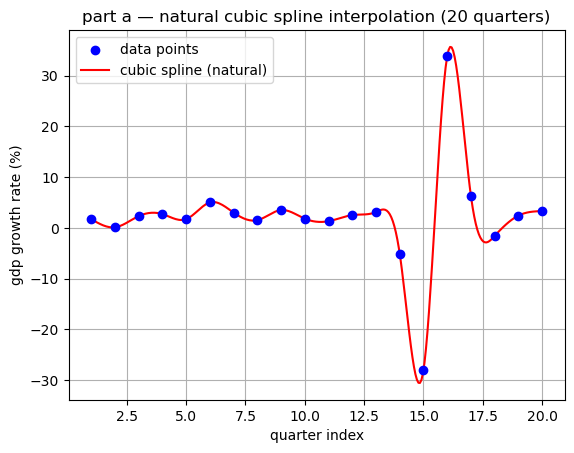

In [3]:
def evaluate_spline(xeval, x_data, y_data, M_vals, h_vals):
    y_out = np.zeros(len(xeval))
    for k in range(len(xeval)):
        for i in range(len(x_data) - 1):
            if x_data[i] <= xeval[k] <= x_data[i + 1]:
                a_coef = (M_vals[i + 1] - M_vals[i]) / (6 * h_vals[i])
                b_coef = M_vals[i] / 2
                c_coef = (y_data[i + 1] - y_data[i]) / h_vals[i] - h_vals[i] * (2 * M_vals[i] + M_vals[i + 1]) / 6
                d_coef = y_data[i]
                dx     = xeval[k] - x_data[i]
                y_out[k] = a_coef * dx**3 + b_coef * dx**2 + c_coef * dx + d_coef
                break
    return y_out

# smooth x range for plotting
x_smooth = np.linspace(x[0], x[-1], 300)
y_smooth = evaluate_spline(x_smooth, x, y, M, h)

plt.figure()
plt.scatter(x, y, color="blue", label="data points", zorder=5)
plt.plot(x_smooth, y_smooth, color="red", label="cubic spline (natural)")
plt.xlabel("quarter index")
plt.ylabel("gdp growth rate (%)")
plt.title("part a — natural cubic spline interpolation (20 quarters)")
plt.legend()
plt.grid(True)
plt.show()

# A2. 

Yes it is visually smooth and we can see that it passes through each point exactly. 

It is mostly reasonable except for the Covid quarters where there a 20% drop and then a sudden 60 % rise which creates a drastic change in our graph, but we know this will happen with cubic spline graphs since we are supposed to pass through these values exactly. beyond our data, this is not a smart method as a policy maker to forecast future data since we have no constraints and can theoretically head into any economic direciton we want. 

# A3. 

The runge phenomenon is a curve's tendency to pass through extreme data values thus causing wild oscilations in order to accomodate it. it applies to high degree polynomials but also splines with outliers. 

The trade off between exact interpolation and numerical stability is that there is no room for error in exact interpolation which then leads to exact fitting. This leaves no room for extreme outliers which is not real world like. 

smoothing splines would be preferrable. smoothing splines dont do exact interpolation but rather they minimize fit error along with total curvature. 

weighted least squares would be preferable as well since we can assign each data point a weight (give the COVID quarters a little amount of weight) and would result in a consistent trend.

# lets see a full 55 quarter evaluation and what will happen after we have no intermediate data left to curve fit.



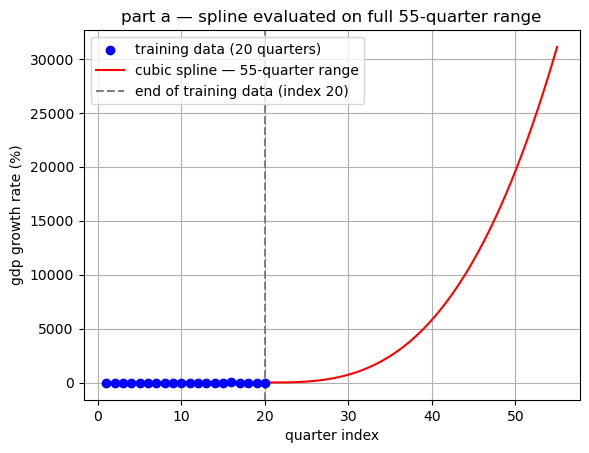

In [4]:
x_full = np.linspace(1, 55, 500)

def evaluate_spline_extrap(xeval, x_data, y_data, M_vals, h_vals):
    y_out = np.zeros(len(xeval))
    for k in range(len(xeval)):
        xk = xeval[k]
        if xk >= x_data[-1]:
            i = len(x_data) - 2
        elif xk <= x_data[0]:
            i = 0
        else:
            for i in range(len(x_data) - 1):
                if x_data[i] <= xk <= x_data[i + 1]:
                    break
        a_coef = (M_vals[i + 1] - M_vals[i]) / (6 * h_vals[i])
        b_coef = M_vals[i] / 2
        c_coef = (y_data[i + 1] - y_data[i]) / h_vals[i] - h_vals[i] * (2 * M_vals[i] + M_vals[i + 1]) / 6
        d_coef = y_data[i]
        dx     = xk - x_data[i]
        y_out[k] = a_coef * dx**3 + b_coef * dx**2 + c_coef * dx + d_coef
    return y_out

y_full = evaluate_spline_extrap(x_full, x, y, M, h)

# plot spline over  55 quarters 
plt.figure()
plt.scatter(x, y, color="blue", label="training data (20 quarters)", zorder=5)
plt.plot(x_full, y_full, color="red", label="cubic spline — 55-quarter range")
plt.axvline(x=x[-1], color="gray", linestyle="--", label="end of training data (index 20)")
plt.xlabel("quarter index")
plt.ylabel("gdp growth rate (%)")
plt.title("part a — spline evaluated on full 55-quarter range")
plt.legend()
plt.grid(True)
plt.show()

# Big O?

as a policy maker, our hand built thomas algorithm ( no libraries for help) means that we are working with 0(n) time so if we double the number of data quarters its safe to assume that the time also double roughly. a general matrix solver has a big O of O(n^3) which is a huge difference and would make the time increase by 8 times instead of 2. as a policymaker or government agency this is definitely something to consider and make a big difference.  our spline code can be updated quickly especially when only considering a few quartesr we're trying to estimate. 

# Part B Polynomial fitting and least squares comparison 

In [5]:
import numpy as np 
import matplotlib.pyplot as plt
import time
import math

degree = 4

# build vandermonde matrix with each row is [x^0, x^1, x^2, x^3, x^4]
n_pts = len(x)
vander = np.zeros((n_pts, degree + 1), dtype=float)
for i in range(n_pts):
    for j in range(degree + 1):
        vander[i, j] = x[i] ** j


cond_num = np.linalg.cond(vander.T @ vander)
print(f"condition number of ATA: {cond_num:.4e}")


ATA = vander.T @ vander
ATy = vander.T @ y

poly_coeffs = np.linalg.solve(ATA, ATy)

#
print("degree-4 polynomial coefficients [c0, c1, c2, c3, c4]:")
for k, c in enumerate(poly_coeffs):
    print(f"  c{k} = {c:.6f}")


condition number of ATA: 2.3325e+11
degree-4 polynomial coefficients [c0, c1, c2, c3, c4]:
  c0 = -4.137371
  c1 = 4.442419
  c2 = -0.823720
  c3 = 0.054471
  c4 = -0.001172


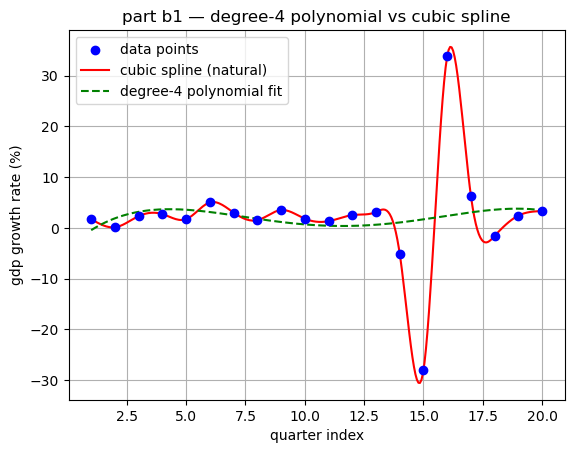

polynomial RMSE: 9.9653%
spline RMSE:     0.000000%


In [6]:
def eval_poly(xeval, coeffs):
    deg = len(coeffs) - 1
    y_out = np.zeros(len(xeval))
    for k in range(len(xeval)):
        for j in range(deg + 1):
            y_out[k] += coeffs[j] * (xeval[k] ** j)
    return y_out

x_plot       = np.linspace(x[0], x[-1], 300)
y_poly_plot  = eval_poly(x_plot, poly_coeffs)
y_spline_plot = evaluate_spline(x_plot, x, y, M, h)

# plot: degree-4 polynomial vs cubic spline
plt.figure()
plt.scatter(x, y, color="blue", label="data points", zorder=5)
plt.plot(x_plot, y_spline_plot, color="red",   label="cubic spline (natural)")
plt.plot(x_plot, y_poly_plot,   color="green", linestyle="--", label="degree-4 polynomial fit")
plt.xlabel("quarter index")
plt.ylabel("gdp growth rate (%)")
plt.title("part b1 — degree-4 polynomial vs cubic spline")
plt.legend()
plt.grid(True)
plt.show()

#RSME and residuals for both

y_poly_at_x    = eval_poly(x, poly_coeffs)
residuals_poly = y - y_poly_at_x
rmse_poly      = math.sqrt(np.mean(residuals_poly ** 2))


y_spline_at_x    = evaluate_spline(x, x, y, M, h)
residuals_spline = y - y_spline_at_x
rmse_spline      = math.sqrt(np.mean(residuals_spline ** 2))

print(f"polynomial RMSE: {rmse_poly:.4f}%")
print(f"spline RMSE:     {rmse_spline:.6f}%")

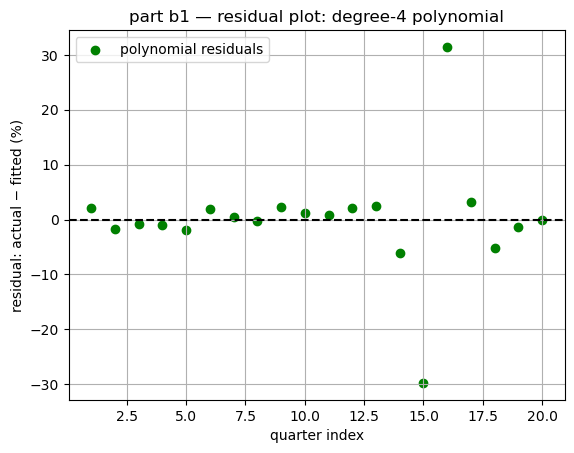

In [7]:
plt.figure()
plt.scatter(x, residuals_poly, color="green", label="polynomial residuals")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("quarter index")
plt.ylabel("residual: actual − fitted (%)")
plt.title("part b1 — residual plot: degree-4 polynomial")
plt.legend()
plt.grid(True)
plt.show()

# B1. 

I believe the degree-4 polynomial better captures the overall trend and we can see this as the curve smooths out COVID outliers and gives us a continueous curve. this allows for a better GDP growth  across the time period without a pandemic to throw things off. 

the cubic spline clearly better models the specific data points and it makes since that is what it was made for. it passes exactly through all 20 known values and an RMSE of basically zero in comparison to the RMSE of the polynomial fit which much more present. 

the trade off between the two is the local exact accuracy of spline interpolation vs. approximation with polynomial fitting with smoother curve better fit for overall overall trend and predicting. for a trend analysis definitely go with polynomial but if we're only looking for  a value between two known values spline is desirable. 

# lets now analyze a linear least squares 




In [10]:
covid_idx  = {14.0, 15.0, 16.0, 17.0}
mask       = np.array([xi not in covid_idx for xi in x])
x_no_covid = x[mask]
y_no_covid = y[mask]

#
print(f"points used for linear fit (covid excluded): {len(x_no_covid)}")

# manual least squares — same method as HW5
n_lin  = len(x_no_covid)
sum_x  = np.sum(x_no_covid)
sum_y  = np.sum(y_no_covid)
sum_xy = np.sum(x_no_covid * y_no_covid)
sum_x2 = np.sum(x_no_covid * x_no_covid)

#
m_linear = (n_lin * sum_xy - sum_x * sum_y) / (n_lin * sum_x2 - sum_x ** 2)
b_linear = (sum_y - m_linear * sum_x) / n_lin

print(f"slope (m):     {m_linear:.6f}")
print(f"intercept (b): {b_linear:.6f}")
print(f"linear model:  gdp_growth = {m_linear:.4f} * quarter_index + {b_linear:.4f}")

points used for linear fit (covid excluded): 16
slope (m):     -0.017336
intercept (b): 2.304112
linear model:  gdp_growth = -0.0173 * quarter_index + 2.3041


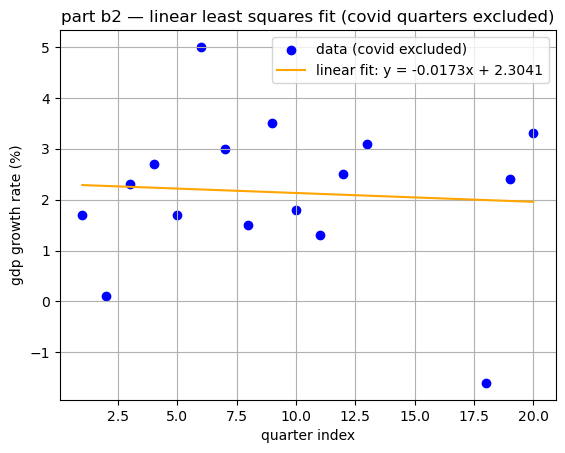

linear fit RMSE (no covid): 1.4400%


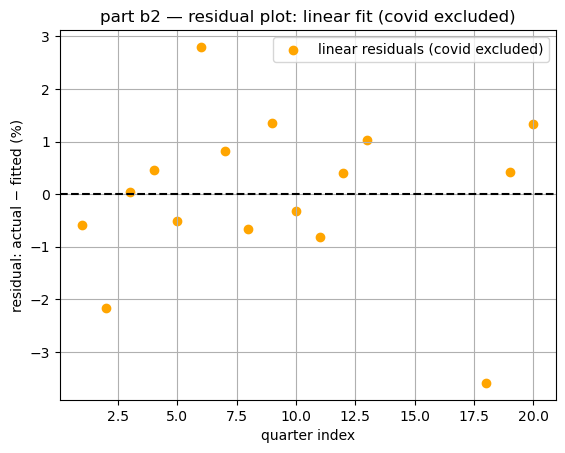

In [13]:
x_lin_plot = np.linspace(x_no_covid[0], x_no_covid[-1], 200)
y_lin_plot = m_linear * x_lin_plot + b_linear

plt.figure()
plt.scatter(x_no_covid, y_no_covid, color="blue", label="data (covid excluded)")
plt.plot(x_lin_plot, y_lin_plot, color="orange", label=f"linear fit: y = {m_linear:.4f}x + {b_linear:.4f}")
plt.xlabel("quarter index")
plt.ylabel("gdp growth rate (%)")
plt.title("part b2 — linear least squares fit (covid quarters excluded)")
plt.legend()
plt.grid(True)
plt.show()


y_lin_at_x    = m_linear * x_no_covid + b_linear
residuals_lin = y_no_covid - y_lin_at_x
rmse_lin      = math.sqrt(np.mean(residuals_lin ** 2))
print(f"linear fit RMSE (no covid): {rmse_lin:.4f}%")

# residual plot
plt.figure()
plt.scatter(x_no_covid, residuals_lin, color="orange", label="linear residuals (covid excluded)")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("quarter index")
plt.ylabel("residual: actual − fitted (%)")
plt.title("part b2 — residual plot: linear fit (covid excluded)")
plt.legend()
plt.grid(True)
plt.show()

# B2.

the slope is -0.0173

the linear trend doesn't suggest a meaningful trend  since the it is nearly flat and is consistent with a mature economy that doesn't fluctuate much in either direction it makes economic sense in this way but isn't really supported through the data.

the assumptions made by this model is 
1. Linearity: that is that growth changes at a constant rate per quarter.which isn't very true since our real GPA goes up and down over time.

2. it assumes homoscedasticity, the variance of residuals is also constant over time. also pretty inconsistent with an economies transitions and recessions.

3. finally independence: each quarter's GPA growth is completely unrelated to the previous which is also very false to real GPA's since strong and weak quarters are usually followed by strong and weak quarters.

# part b big O?

as a policy maker, with our vandermonde and normal equations being 0(n) since d^2 is just a constant. our coefficients, evaluating at any quarter always results in O(d) which is always 4 which is essentially instantaneous. this is faster than the spline model for large numbers of estimates. the trade off is accuracy since economies are hardly linear but the speed is much faster than a spline and definitely something to consider as a policymaker.

# Part C Method comparison summary

In [12]:
start_spline = time.time()
_ = evaluate_spline(x, x, y, M, h)
time_spline  = time.time() - start_spline

start_poly = time.time()
_ = eval_poly(x, poly_coeffs)
time_poly  = time.time() - start_poly

start_lin = time.time()
_ = m_linear * x_no_covid + b_linear
time_lin  = time.time() - start_lin

#
print("===== method comparison summary =====")
print(f"cubic spline     — RMSE: {rmse_spline:.6f}%    eval time: {time_spline:.6f}s")
print(f"poly degree-4    — RMSE: {rmse_poly:.4f}%      eval time: {time_poly:.6f}s")
print(f"linear (no covid)— RMSE: {rmse_lin:.4f}%      eval time: {time_lin:.6f}s")

===== method comparison summary =====
cubic spline     — RMSE: 0.000000%    eval time: 0.000386s
poly degree-4    — RMSE: 9.9653%      eval time: 0.000237s
linear (no covid)— RMSE: 1.4400%      eval time: 0.000107s


# C1

I would personally recommend the cubic spline with a strong note of caution for the COVID quarters since we are finding quarters in between not predicting decades into the future where cubic spline truly fails.

The spline guarantees continuity with no kinks or abrupt jumps from quarter to quarter. this is consistent with normal economic growth.

as far as accuracy justification goes, the spline fit is designed to pass through every data point so any estimate between two quarters is related to two real reported values. the polynomial fit by design misses known data points by its RMSE value since it is used to predict not exact fit. 

the spline's biggest weakness appears here in sensitivity to outliers and specifically the jump from -28.1 % to 33.8% and how this distorts the spline segments and its continuity requirement. for a policymaker interpolating between two normal quarters the spline fit is the way to go, if we are interpolating with quarters near or during the COVID quartes go with the polynomial fit. 

as far as quantitative support goes: the spline RMSE of 0 but the highest time ( still incredibly small) is very consistent with what we stated previously. for our polyfit, we see a RMSE of 9.9653 which isn't a terrible rate and also a lower time ( lower big O time usage). finally our linear fit does hold a smaller RMSE than Polyfit with 1.4400 but this is mainly becuase we excluded the COVID quarters which would drastically change our numbers and it also does have the smallest time which is what we expected. 






# C Big O?

as a policymaker if I need exact values with known data points, the spline with an O(n) build (hand crafted no libraries) zero RMSE and is smooth. If I need a more adaptable fit, the polynomial fit is not thrown off by major crisis's and has a moderate RMSE. If I'm a cheap policymaker who has very simple goals like showing  a small finding, this is the lowest cost for a single point interpolation the least time consuming. 

# AI Use

Citation 1 -Report Outline
AI Tool Used: Claude AI (claude.ai) – Claude Sonnet 4.6

Prompt I Submitted: hey claude!  I have a midterm project for my engineering computation class we have to analyze U.S. GDP growth rate  using three methods we coded
from scratch,  least squares linear regression, polynomial fitting using normal equations, and natural cubic spline interpolation. I already have all the code done from my previous homeworks.

now I need to write a report that has an introduction, part a covering the spline, part b covering

the polynomial and least squares comparison, part c for method justification, and a conclusion.
can you give me a ~200 word outline I can use to organize my writing before I start the full paper?


AI Response (Outline as Provided):
I. Introduction
  •  Dataset: BEA GDP SAAR data, 20 quarters, integer-indexed x = 1–20
  •  Three methods: least squares linear, degree-4 polynomial (normal equations), natural cubic spline
  •  Goal: compare interpolation vs. approximation on real economic data

II. Part A — Cubic Spline
  •  A1: 19 cubics, 76 unknowns; C0/C1/C2 at 18 interior knots; natural BCs M1 = Mn = 0; Thomas O(n)
  •  A2: Smooth within training range; COVID quarters cause local oscillation; extrapolation diverges
  •  A3: Runge-like distortion at COVID knots due to C2 constraint; smoothing splines or weighted LS preferred

III. Part B — Polynomial & Least Squares
  •  B1: Vandermonde + normal equations; check condition number; polynomial approximates, spline interpolates
  •  B2: 16 non-COVID points; manual summation (HW5 method); linear trend weakly supported economically

IV. Part C — Method Justification
  •  Recommend cubic spline for between-quarter interpolation: C2 smooth, exact fit, O(n) build
  •  Caveat: COVID quarters distort spline neighbors; use LS (COVID excluded) for trend analysis
  •  Quantitative support: RMSE, condition number, timing comparison

V. Conclusion
  •  Spline best for interpolation; polynomial best for trend; linear best for communication
  •  Key lesson: method choice depends on goal, not universal performance

How I Used This and What I Changed: I’m not the best writer, so I wanted to optimize my time a bit and get a rough outline just to guide my writing and focus more on the actual code as well as adding in some headers and formatting my notebook and a visually appealing way since its been said this helps with grading. 


Citation 1 -Vandermonde code matrix 


AI Tool Used: Claude AI (claude.ai)- Claude Sonnet 4.6

Prompt I Submitted: Adding on to earlier for my midterm I need to build a vandermonde matrix completely from scratch, I have some notes covering this sortve through my homeworks and I can attach them, but you can generate it on your own. can you show me how to do this? Use relatively simple naming conventions and syntax, keep it to nested for loops since I can’t use any libraries anyway. I will also add how my mid term projects wants this.

AI Response (Code as Provided): 
degree = 4

 build vandermonde matrix of shape (n_pts, degree+1)
 each row is [x^0, x^1, x^2, x^3, x^4]
n_pts = len(x)
vander = np.zeros((n_pts, degree + 1), dtype=float)
for col in range(degree + 1):
    for row in range(n_pts):
        vander[row, col] = x[row] ** col

cond_num = np.linalg.cond(vander.T @ vander)
print(f"condition number of ATA: {cond_num:.4e}")

ATA = vander.T @ vander
ATy = vander.T @ y

poly_coeffs = np.linalg.solve(ATA, ATy)

What I Changed in My Submitted Code and Why: the only thing I changed was for the neseted loops to iterate over my rows which were data points and columns which were polynomial powers. The vandermonde matrix structure remains the same. 


# Conclusion

After all of the number crunching, equation solving, and plots being graphed, we have effectively applied 3 numerical methods to U.S. GDP growth rate data and evaluated a number of things for both interpolation and also trend analysis. as we expected, the cubic spline performed the best for interpolation achieving a zero RMSE and producing a very smooth curve between the points. its biggest sensitivity was to COVID and the big jumps that came with it. cubic splines must meet 3 conditions to be used and during COVID quarters, the continuity requirement is slightly jeopardized. The 4th degree polynomial fit performed the best for the overall points regardless of outliers and efficiently smoothed over these at the cost of local accuracy. Finally, the linear least squares model (excluding COVID) was the time and cost efficient and also held a near zero RMSE percentage. The overhanging idea is that no single method will ever be universally optimal. it is our job as engineers and data scientist to identify our goal and givens and make a best guess at which method can give us the best results. with the help of condition numbers, RMSE and residual plots, we can paint a picture of quantitative data needed to help us make these difficult choices and reach our goals to the best of our abilities!
